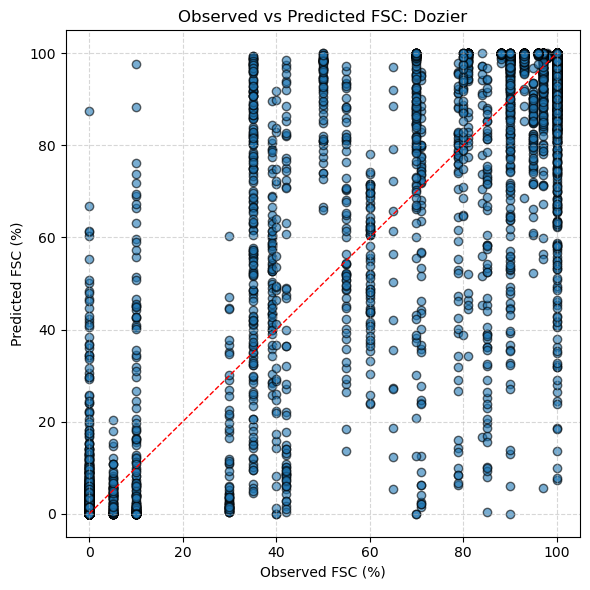

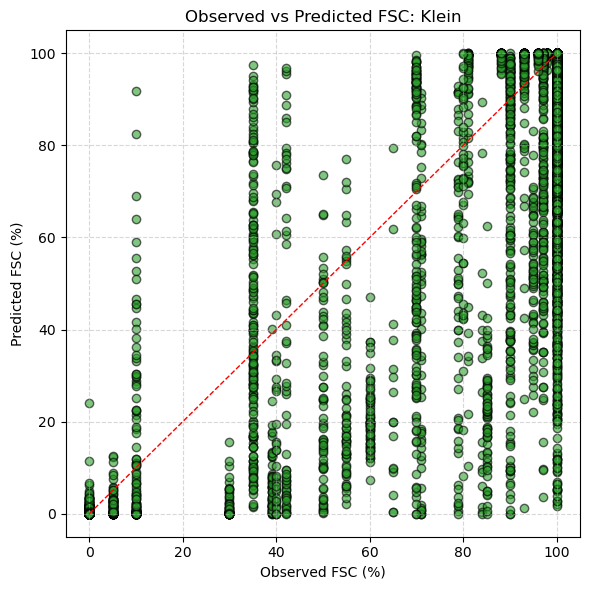

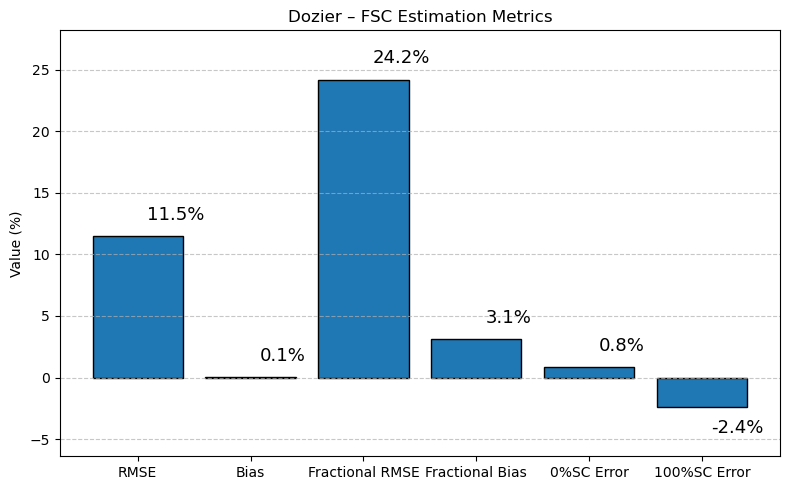

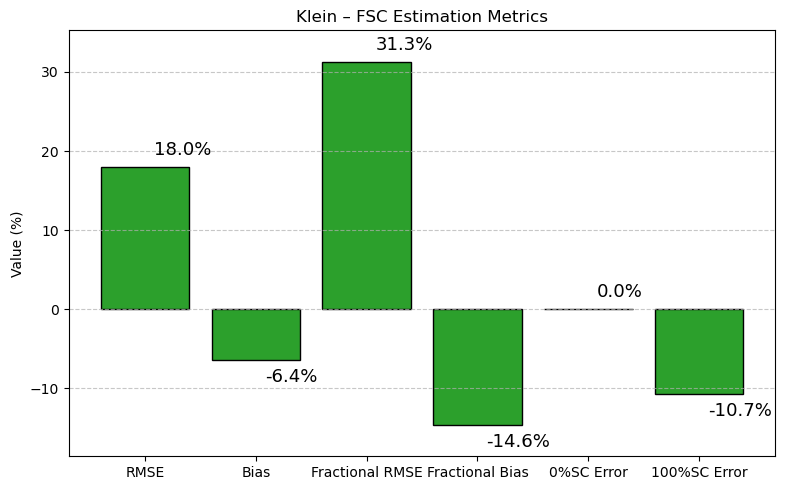

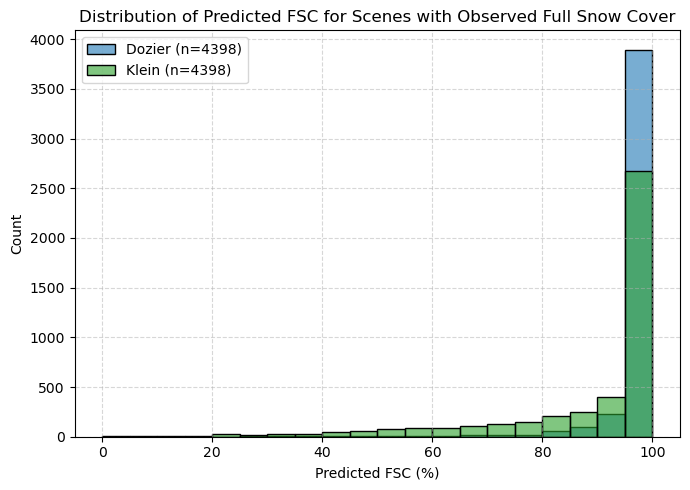

In [1]:
#80m

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

final_df = pd.read_pickle('landsat_aspect_results.pkl')

# final_df = pd.read_pickle('landsat_df_80m_0.2ff.pkl')
# final_df = final_df[final_df['cam']=='old_jack_pine']

# Melt the dataframe to long format for individual method plots
melted = final_df.melt(
    id_vars=["fsc", "filtered_fraction", "cam"],
    value_vars=["Dozier", "Klein"],  # , "Salomonson"
    var_name="method",
    value_name="predicted"
)

# Convert to percentages for plotting (0–100)
melted["fsc"] = melted["fsc"] * 100.0
melted["predicted"] = melted["predicted"] * 100.0

# Define color map (blue for Dozier, green for Klein)
method_colors = {
    "Dozier": "#1f77b4",
    "Klein": "#2ca02c",
    # "Salomonson": "#d62728"
}

# ---------- Scatter: Observed vs Predicted, one figure per method ----------
for method in ["Dozier", "Klein"]:  # , "Salomonson"
    subset = melted[melted["method"] == method]

    plt.figure(figsize=(6, 6))
    plt.scatter(
        subset["fsc"],
        subset["predicted"],
        alpha=0.6,
        edgecolor='k',
        c=method_colors[method],
        label=method
    )
    plt.plot([0, 100], [0, 100], 'r--', lw=1)
    plt.xlabel("Observed FSC (%)")
    plt.ylabel("Predicted FSC (%)")
    plt.title(f"Observed vs Predicted FSC: {method}")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    # plt.savefig(f'poster_landsat_{method}_actual_predicted.svg')
    plt.show()

# ---------- Metric helpers ----------
def rmse(y_true, y_pred):
    diff = y_pred - y_true
    return np.sqrt(np.nanmean(diff**2)) if np.isfinite(diff).any() else np.nan

def bias(y_true, y_pred):
    diff = y_pred - y_true
    return np.nanmean(diff) if np.isfinite(diff).any() else np.nan

def compute_all_metrics(df_method):
    """df_method: melted subset for a single method, with fsc/predicted in 0–100 units."""
    y = df_method["fsc"].to_numpy()
    yhat = df_method["predicted"].to_numpy()

    # Overall
    overall_rmse  = rmse(y, yhat)
    overall_bias  = bias(y, yhat)

    # Fractional (strictly between 0 and 100)
    frac_mask = (y > 0) & (y < 100)
    frac_rmse  = rmse(y[frac_mask], yhat[frac_mask])
    frac_bias  = bias(y[frac_mask], yhat[frac_mask])

    # Errors at the extremes
    zero_mask = (y == 0)
    full_mask = (y == 100)

    zero_bias = bias(y[zero_mask], yhat[zero_mask])   # "0%SC Error"
    full_bias = bias(y[full_mask], yhat[full_mask])   # "100%SC Error"

    metrics_order = ["RMSE", "Bias", "Fractional RMSE", "Fractional Bias", "0%SC Error", "100%SC Error"]
    values = np.array([
        overall_rmse,
        overall_bias,
        frac_rmse,
        frac_bias,
        zero_bias,
        full_bias
    ], dtype=float)

    return metrics_order, values

# ---------- Bar chart per method with six metrics ----------
for method in ["Dozier", "Klein"]:
    subset = melted[melted["method"] == method]
    metrics_labels, values = compute_all_metrics(subset)

    plt.figure(figsize=(8, 5))
    x = np.arange(len(metrics_labels))
    bars = plt.bar(x, values, edgecolor='black', color=method_colors[method])

    # Labels on bars (handle NaNs gracefully)
    for bar, val in zip(bars, values):
        height = 0 if np.isnan(val) else float(val)
        txt = "NaN" if np.isnan(val) else f"{height:.1f}%"
        x_offset = bar.get_x() + bar.get_width() * 0.6
        y_offset = 1 * np.sign(height if height != 0 else 1)
        plt.text(
            x_offset,
            height + y_offset,
            txt,
            ha='left',
            va='bottom' if height >= 0 else 'top',
            fontsize=13
        )

    plt.xticks(x, metrics_labels, rotation=0)
    plt.ylabel("Value (%)")
    plt.title(f"{method} – FSC Estimation Metrics")
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Y-lims with padding, robust to NaNs
    finite_vals = values[np.isfinite(values)]
    if finite_vals.size == 0:
        ymin, ymax = -1, 1
    else:
        ymin = min(0.0, float(finite_vals.min())) - 4
        ymax = (float(finite_vals.max()) + 4) if float(finite_vals.max()) > 0 else 1
    plt.ylim(ymin, ymax)

    plt.tight_layout()
    # plt.savefig(f'poster_landsat_{method}_metrics.svg')
    plt.show()

# ---------- Histogram: Predicted FSC where observed FSC = 100% ----------

# Filter scenes where observed FSC is 100%
full_snow = melted[melted["fsc"] == 100].copy()

# Set up plot
plt.figure(figsize=(7, 5))
bins = np.linspace(0, 100, 21)  # 0–100 in 5% increments

for method in ["Dozier", "Klein"]:
# for method in ["Klein"]:
    subset = full_snow[full_snow["method"] == method]
    sns.histplot(
        subset["predicted"],
        bins=bins,
        kde=False,
        color=method_colors[method],
        label=f"{method} (n={len(subset)})",
        alpha=0.6,
        edgecolor="black"
    )

# Reference line at 100% (perfect prediction)
# plt.axvline(100, color="red", linestyle="--", linewidth=1, label="Observed = 100%")

plt.xlabel("Predicted FSC (%)")
plt.ylabel("Count")
plt.title("Distribution of Predicted FSC for Scenes with Observed Full Snow Cover")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
# plt.savefig("poster_landsat_full_snow_hist.svg")
plt.show()

In [2]:
final_df.columns

Index(['sampling_mode', 'grid_row', 'grid_col', 'grid_cell_id', 'sim_id',
       'beam_pair', 'anchor_beam_pair', 'anchor_edge', 'orientation',
       'offset_m', 'lat_bin', 'lat_bin_y_min', 'lat_bin_y_max', 'track_x0',
       'track_y0', 'track_x1', 'track_y1', 'box_center_lon', 'box_center_lat',
       'box_center_x', 'box_center_y', 'box_left', 'box_right', 'box_bottom',
       'box_top', 'pixel_count', 'valid_pixel_count', 'filtered_fraction',
       'north_facing_fraction', 'aspect_variability', 'gradient_p16',
       'gradient_p50', 'gradient_p84', 'topography_valid_pixel_count',
       'ndsi_mean', 'ndsi_p16', 'ndsi_p50', 'ndsi_p84', 'ndvi_mean',
       'ndvi_p16', 'ndvi_p50', 'ndvi_p84', 'green_mean', 'green_p16',
       'green_p50', 'green_p84', 'red_mean', 'red_p16', 'red_p50', 'red_p84',
       'nir_mean', 'nir_p16', 'nir_p50', 'nir_p84', 'swir_mean', 'swir_p16',
       'swir_p50', 'swir_p84', 'Dozier', 'Klein', 'Salomonson', 'fsc', 'cam',
       'filepath', 'landsat_scene_i

In [13]:
# final_df[final_df['fsc']==1.00].filepath.unique()

In [14]:
final_df

,sampling_mode,grid_row,grid_col,grid_cell_id,sim_id,beam_pair,anchor_beam_pair,anchor_edge,orientation,offset_m,...,swir_p16,swir_p50,swir_p84,Dozier,Klein,Salomonson,fsc,cam,filepath,landsat_scene_index
0,regular_grid_cells,0,0,r0_c0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.135480,0.170014,0.201670,0.025210,0.000000,0.012350,0.71,delta_junction,../scratch/data/landsat_oursites_L1_GEE/TOA/La...,0
1,regular_grid_cells,0,1,r0_c1,NaN,NaN,NaN,NaN,NaN,NaN,...,0.118213,0.149869,0.178647,0.062706,0.004967,0.032267,0.71,delta_junction,../scratch/data/landsat_oursites_L1_GEE/TOA/La...,0
2,regular_grid_cells,0,2,r0_c2,NaN,NaN,NaN,NaN,NaN,NaN,...,0.118443,0.152747,0.172892,0.091413,0.019553,0.039766,0.71,delta_junction,../scratch/data/landsat_oursites_L1_GEE/TOA/La...,0
3,regular_grid_cells,0,4,r0_c4,NaN,NaN,NaN,NaN,NaN,NaN,...,0.123969,0.144114,0.161381,0.014440,0.000000,0.008906,0.71,delta_junction,../scratch/data/landsat_oursites_L1_GEE/TOA/La...,0
4,regular_grid_cells,0,5,r0_c5,NaN,NaN,NaN,NaN,NaN,NaN,...,0.123969,0.149869,0.167136,0.020888,0.007833,0.013176,0.71,delta_junction,../scratch/data/landsat_oursites_L1_GEE/TOA/La...,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12157,regular_grid_cells,5,5,r5_c5,NaN,NaN,NaN,NaN,NaN,NaN,...,0.015351,0.033372,0.048457,0.826134,0.746220,0.876894,1.00,wslcreek,../scratch/data/landsat_oursites_L1_GEE/TOA/La...,248
12158,regular_grid_cells,5,6,r5_c6,NaN,NaN,NaN,NaN,NaN,NaN,...,0.015775,0.023698,0.030631,0.762014,0.503433,0.829601,1.00,wslcreek,../scratch/data/landsat_oursites_L1_GEE/TOA/La...,248
12159,regular_grid_cells,6,4,r6_c4,NaN,NaN,NaN,NaN,NaN,NaN,...,0.027061,0.039225,0.053125,1.000000,0.963671,0.805782,1.00,wslcreek,../scratch/data/landsat_oursites_L1_GEE/TOA/La...,248
12160,regular_grid_cells,6,5,r6_c5,NaN,NaN,NaN,NaN,NaN,NaN,...,0.015386,0.020497,0.025775,0.762976,0.413495,0.856751,1.00,wslcreek,../scratch/data/landsat_oursites_L1_GEE/TOA/La...,248


Number of Landsat scenes: 249
Number of 0% or 100% scenes: 207
Processing i=4: ../scratch/data/landsat_oursites_L1_GEE/TOA/Landsat7_marcell100_LE07_L1TP_028027_20200326_20200822_02_T1.tif
Landsat7 SR (as-is) mean/min/max: 46.435115814208984 -0.013624859042465687 275.9427185058594
marcell: reference=100% | valid-mask pixels=54,212 | common evaluated pixels=41,310
Processing i=17: ../scratch/data/landsat_oursites_L1_GEE/TOA/Landsat8_bartlett0_LC08_L1TP_012029_20200926_20201006_02_T1.tif
Landsat8 SR (as-is) mean/min/max: 0.13015645742416382 0.005550930742174387 0.5961518287658691
bartlett: reference=0% | valid-mask pixels=27,070 | common evaluated pixels=26,632
Processing i=18: ../scratch/data/landsat_oursites_L1_GEE/TOA/Landsat8_bartlett0_LC08_L1TP_012029_20210524_20210529_02_T1.tif
Landsat8 SR (as-is) mean/min/max: 0.1337837278842926 -0.000430520303780213 0.6185896992683411
bartlett: reference=0% | valid-mask pixels=27,070 | common evaluated pixels=26,632
Processing i=19: ../scratch/dat

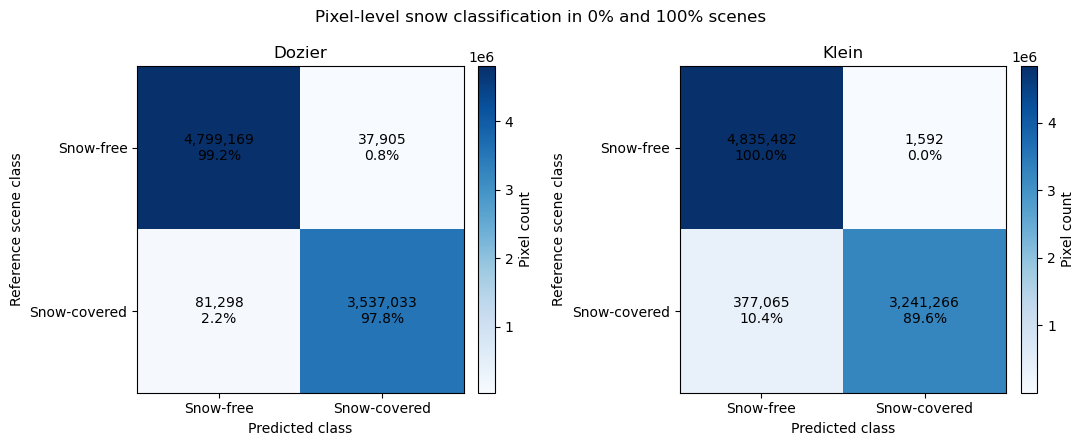

In [15]:
from scripts.imports import *
from rasterio.enums import Resampling
from shapely.geometry import Polygon, Point
from pyproj import Transformer
import os
import re
import gc
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

# ------------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------------
# positions for SR bands in your stacks (already reflectance)
L7_SR_IDX = slice(0, 6)   # SR_B1..SR_B5, SR_B7
L8_SR_IDX = slice(0, 7)   # SR_B1..SR_B7

USE_SIMULATED_TRACKS = False
PLOT_RGB_IMAGE = False
PLOT_SIMULATED_TRACKS = True
APPLY_MIN_FILTERED_FRACTION_TO_GRID_CELLS = True

PLOT_SNOW_PRODUCT_MAPS = False
PLOT_SALOMONSON_MAP = False

# Folder containing your reflectance Landsat stacks
LANDSAT_FOLDER = '../scratch/data/landsat_oursites_L1_GEE/TOA/'

# Topography data
LANDSAT_MASKING_FOLDER = '../scratch/data/landsat_masking/'

# WorldCover data
WC_FOLDER = '../scratch/data/WC/'
WC_FOREST_VALUE = 10

WC_NAME_MAP = {
    "sodankyla": "sodankyla_full",
    "marcell": "marcell_MN",
    "oregon": "oregon_yp",
}

# ROI options
USE_ROI = False
ROI_LON = -105.90
ROI_LAT = 53.92
ROI_HALF_WIDTH_M = 26000
ROI_HALF_HEIGHT_M = 26000

# Simulated ICESat-2 settings
N_TRACK_SIMS = 1
ICESAT2_PAIR_SPACING_M = 3300
ICESAT2_INCLINATION_DEG = 92
TRACK_LAT_BINS = 8
TRACK_BOX_SIZE_M = 1000
TRACK_MIN_FILTERED_FRACTION = 0.2
RNG_SEED = 42
N_BEAM_PAIRS = 1

# Regular grid-cell mode settings
GRID_N_X = 8
GRID_N_Y = 8
GRID_CELL_SIZE_M = 1000

# Spectral variables to summarise within each sampled cell.
# These include all direct inputs to the Dozier and Klein algorithms,
# plus the source bands used to calculate NDSI and NDVI.
SPECTRAL_VARIABLES = (
    "ndsi",
    "ndvi",
    "green",
    "red",
    "nir",
    "swir",
)


# ------------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------------
def _sr_slice(landsat_type):
    return L7_SR_IDX if landsat_type == 'Landsat7' else L8_SR_IDX


def extract_core_sr(landsat_da, landsat_type):
    """
    Return blue, green, red, nir, swir1 as reflectance,
    with consistent meanings across sensors.
    """
    if landsat_type == 'Landsat7':
        blue  = landsat_da.isel(band=0)
        green = landsat_da.isel(band=1)
        red   = landsat_da.isel(band=2)
        nir   = landsat_da.isel(band=3)
        swir1 = landsat_da.isel(band=4)
    else:
        blue  = landsat_da.isel(band=1)
        green = landsat_da.isel(band=2)
        red   = landsat_da.isel(band=3)
        nir   = landsat_da.isel(band=4)
        swir1 = landsat_da.isel(band=5)

    return blue, green, red, nir, swir1


def find_masks(masking_folder, wc_folder, cam):
    """
    Find:
      - WorldCover landcover from WC_FOLDER
      - ALOS elevation / gradient / aspect from LANDSAT_MASKING_FOLDER
    """
    wc_cam_name = WC_NAME_MAP.get(cam, cam)
    landcover_filepath = os.path.join(wc_folder, f"{wc_cam_name}.tif")

    elevation_filepath = None
    gradient_filepath = None
    aspect_filepath = None

    for filename in os.listdir(masking_folder):
        filename_lower = filename.lower()

        if (
            cam in filename
            and "elevation" in filename_lower
            and filename_lower.endswith(".tif")
        ):
            elevation_filepath = os.path.join(masking_folder, filename)

        elif (
            cam in filename
            and "gradient" in filename_lower
            and filename_lower.endswith(".tif")
        ):
            gradient_filepath = os.path.join(masking_folder, filename)

        elif (
            cam in filename
            and "aspect" in filename_lower
            and filename_lower.endswith(".tif")
        ):
            aspect_filepath = os.path.join(masking_folder, filename)

    if (
        not os.path.exists(landcover_filepath)
        or elevation_filepath is None
        or gradient_filepath is None
        or aspect_filepath is None
    ):
        raise FileNotFoundError(
            f"Could not find all required files for {cam}\n"
            f"  WorldCover expected: {landcover_filepath}\n"
            f"  ALOS elevation found: {elevation_filepath}\n"
            f"  ALOS gradient found:  {gradient_filepath}\n"
            f"  ALOS aspect found:    {aspect_filepath}"
        )

    return landcover_filepath, elevation_filepath, gradient_filepath, aspect_filepath


def load_and_reproject_to_landsat(source_path, match_array, band_name, method=Resampling.nearest):
    """
    Minimal memory-safe version of the original function.

    The important change is that the source raster is closed after
    reproject_match has created the matched output.
    """
    src = rioxarray.open_rasterio(source_path, masked=True).squeeze()
    src.name = band_name

    try:
        out = src.rio.reproject_match(match_array, resampling=method)
        out.name = band_name
    finally:
        try:
            src.close()
        except Exception:
            pass
        del src

    return out


def subset_roi(da, centre_lon, centre_lat, half_width_m, half_height_m):
    """
    Subset a DataArray to a rectangular ROI around lon/lat,
    using the dataset's CRS and units.
    """
    if da.rio.crs is None:
        raise ValueError("Dataset has no CRS; cannot subset by lon/lat.")

    transformer = Transformer.from_crs("EPSG:4326", da.rio.crs, always_xy=True)
    cx, cy = transformer.transform(centre_lon, centre_lat)

    minx = cx - half_width_m
    maxx = cx + half_width_m
    miny = cy - half_height_m
    maxy = cy + half_height_m

    return da.rio.clip_box(minx=minx, miny=miny, maxx=maxx, maxy=maxy)


def combine_tifs(
    landsat_filepath,
    landcover_filepath,
    elevation_filepath,
    gradient_filepath,
    aspect_filepath,
    landsat_type,
    use_roi=False
):
    """
    Load Landsat reflectance stack + WorldCover landcover + elevation
    + gradient + aspect, all on the same Landsat grid.
    """
    landsat = rioxarray.open_rasterio(landsat_filepath, masked=True).squeeze()
    landsat.name = "landsat"

    if use_roi:
        print("  Applying ROI crop to Landsat...")
        landsat = subset_roi(
            landsat,
            centre_lon=ROI_LON,
            centre_lat=ROI_LAT,
            half_width_m=ROI_HALF_WIDTH_M,
            half_height_m=ROI_HALF_HEIGHT_M,
        )

    landcover = load_and_reproject_to_landsat(
        landcover_filepath,
        landsat,
        "landcover",
        method=Resampling.nearest
    )

    elevation = load_and_reproject_to_landsat(
        elevation_filepath,
        landsat,
        "elevation",
        method=Resampling.bilinear
    )

    gradient = load_and_reproject_to_landsat(
        gradient_filepath,
        landsat,
        "gradient",
        method=Resampling.bilinear
    )

    aspect = load_and_reproject_to_landsat(
        aspect_filepath,
        landsat,
        "aspect",
        method=Resampling.nearest
    )

    if use_roi:
        landcover = subset_roi(
            landcover,
            centre_lon=ROI_LON,
            centre_lat=ROI_LAT,
            half_width_m=ROI_HALF_WIDTH_M,
            half_height_m=ROI_HALF_HEIGHT_M,
        )

        elevation = subset_roi(
            elevation,
            centre_lon=ROI_LON,
            centre_lat=ROI_LAT,
            half_width_m=ROI_HALF_WIDTH_M,
            half_height_m=ROI_HALF_HEIGHT_M,
        )

        gradient = subset_roi(
            gradient,
            centre_lon=ROI_LON,
            centre_lat=ROI_LAT,
            half_width_m=ROI_HALF_WIDTH_M,
            half_height_m=ROI_HALF_HEIGHT_M,
        )

        aspect = subset_roi(
            aspect,
            centre_lon=ROI_LON,
            centre_lat=ROI_LAT,
            half_width_m=ROI_HALF_WIDTH_M,
            half_height_m=ROI_HALF_HEIGHT_M,
        )

    ds = xr.merge([landsat, landcover, elevation, gradient, aspect])

    # Remove local references. The merged Dataset keeps what it needs.
    del landcover, elevation, gradient, aspect

    return ds


def apply_valid_mask(ds, e=80):
    elevation = ds['elevation']
    landcover = ds['landcover']

    yc, xc = elevation.sizes['y'] // 2, elevation.sizes['x'] // 2
    centre_elev = elevation.isel(y=yc, x=xc).item()

    elev_mask = np.abs(elevation - centre_elev) <= e

    # ESA WorldCover class 10 = tree cover / forest
    landcover_mask = landcover == WC_FOREST_VALUE

    valid_mask = elev_mask & landcover_mask
    ds['valid_mask'] = valid_mask

    return ds


def compute_index(b1, b2):
    denom = b1 + b2
    return xr.where(denom != 0, (b1 - b2) / denom, np.nan)


def compute_dozier(ds, ndsi, nir):
    condition1 = (ndsi > 0.1) & (ndsi < 0.4)
    condition2 = (ndsi >= 0.4) & (nir > 0.11)
    dozier = xr.where(condition1 | condition2, 1, 0)
    return dozier.where(~np.isnan(ndsi))


def compute_klein(ndsi, ndvi, green, nir):
    region_coords = [
        (0.4, 1),
        (0.4, 0.1),
        (0.1, 0.24516133),
        (0.1125, 0.29378870),
        (0.125, 0.34092437),
        (0.175, 0.51454990),
        (0.2, 0.59241240),
        (0.25, 0.73023683),
        (0.275, 0.79019879),
        (0.325, 0.89222209)
    ]

    polygon = Polygon(region_coords)
    klein = xr.zeros_like(ndsi)
    klein = xr.where((ndsi >= 0.4) & (nir > 0.11), 1, klein)

    ndsi_vals = ndsi.values
    ndvi_vals = ndvi.values
    mask = np.zeros(ndsi.shape, dtype=bool)

    for i in range(ndsi.shape[0]):
        for j in range(ndsi.shape[1]):
            if not np.isnan(ndsi_vals[i, j]) and not np.isnan(ndvi_vals[i, j]):
                if polygon.contains(Point(ndsi_vals[i, j], ndvi_vals[i, j])):
                    mask[i, j] = True

    klein = xr.where(
        xr.DataArray(mask, dims=ndsi.dims, coords=ndsi.coords),
        1,
        klein
    )

    klein = xr.where((green <= 0.1), 0, klein)

    out = klein.where(~np.isnan(ndsi) & ~np.isnan(ndvi))

    # Minimal cleanup of the full numpy arrays used inside this function.
    del ndsi_vals, ndvi_vals, mask

    return out


def compute_salomonson(ndsi):
    fsc = 0.06 + 1.21 * ndsi
    return fsc.clip(0, 1).where(~np.isnan(ndsi))


def normalize(img):
    img = img.transpose("y", "x", "band")
    p2 = img.quantile(0.02, dim=("x", "y"))
    p98 = img.quantile(0.98, dim=("x", "y"))
    return ((img - p2) / (p98 - p2)).clip(0, 1)


def plot_rgb_with_tracks(ds, landsat_type, cam, track_stats=None, filtered=False):
    blue, green, red, _, _ = extract_core_sr(ds['landsat'], landsat_type)
    rgb = xr.concat([red, green, blue], dim='band')

    if filtered and 'valid_mask' in ds:
        rgb = rgb.where(ds['valid_mask'])

    rgb = normalize(rgb)
    rgb_img = rgb.transpose("y", "x", "band").values

    x_vals = ds["x"].values
    y_vals = ds["y"].values

    x_min, x_max = float(np.nanmin(x_vals)), float(np.nanmax(x_vals))
    y_min, y_max = float(np.nanmin(y_vals)), float(np.nanmax(y_vals))

    fig, ax = plt.subplots(figsize=(8, 8))

    ax.imshow(
        rgb_img,
        extent=[x_min, x_max, y_min, y_max],
        origin="upper"
    )

    if track_stats is not None and not track_stats.empty:
        sim_ids = sorted(track_stats["sim_id"].dropna().unique())
        cmap = plt.cm.tab10
        sim_colors = {
            sim_id: cmap((int(sim_id) - 1) % 10)
            for sim_id in sim_ids
        }

        track_cols = [
            "sim_id", "beam_pair",
            "track_x0", "track_y0",
            "track_x1", "track_y1",
            "anchor_beam_pair",
            "orientation"
        ]

        unique_tracks = (
            track_stats[track_cols]
            .drop_duplicates()
            .dropna(subset=["track_x0", "track_y0", "track_x1", "track_y1"])
        )

        for _, tr in unique_tracks.iterrows():
            sim_id = tr["sim_id"]
            beam_pair = int(tr["beam_pair"])
            color = sim_colors[sim_id]

            is_anchor = beam_pair == int(tr["anchor_beam_pair"])

            ax.plot(
                [tr["track_x0"], tr["track_x1"]],
                [tr["track_y0"], tr["track_y1"]],
                color=color,
                linewidth=2.4 if is_anchor else 1.5,
                linestyle="-" if is_anchor else "--",
                alpha=0.95,
                zorder=5
            )

            ax.text(
                tr["track_x0"],
                tr["track_y0"],
                f"S{int(sim_id)}-BP{beam_pair}",
                color=color,
                fontsize=8,
                weight="bold" if is_anchor else "normal",
                zorder=7
            )

        for _, row in track_stats.iterrows():
            color = sim_colors[row["sim_id"]]

            rect = Rectangle(
                (row["box_left"], row["box_bottom"]),
                row["box_right"] - row["box_left"],
                row["box_top"] - row["box_bottom"],
                fill=False,
                edgecolor=color,
                linewidth=1.2,
                alpha=0.85,
                zorder=6
            )
            ax.add_patch(rect)

            ax.scatter(
                row["box_center_x"],
                row["box_center_y"],
                s=12,
                color=color,
                zorder=8
            )

        legend_handles = [
            Line2D(
                [0], [0],
                color=sim_colors[sim_id],
                lw=2,
                label=f"Simulation {int(sim_id)}"
            )
            for sim_id in sim_ids
        ]

        legend_handles.extend([
            Line2D([0], [0], color="black", lw=2.4, linestyle="-", label="Anchor beam pair"),
            Line2D([0], [0], color="black", lw=1.5, linestyle="--", label="Offset beam pair"),
            Rectangle((0, 0), 1, 1, fill=False, edgecolor="black", label="1 km box")
        ])

        ax.legend(
            handles=legend_handles,
            loc="upper right",
            fontsize=8,
            frameon=True
        )

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------------
# PER-SCENE PROCESSING
# ------------------------------------------------------------------
def process_scene(i, apply_filter=True, e=80):
    cams = [
        'bartlett', 'delta_junction', 'glees', 'hyytiala', 'kenttarova',
        'lacclair', 'marcell', 'old_jack_pine', 'oregon', 'queens',
        'sodankyla', 'tammela', 'torgnon', 'underc', 'underhill',
        'varrio', 'willowcreek', 'wslcreek'
    ]

    landsat_filepaths = sorted([
        os.path.join(LANDSAT_FOLDER, f) for f in os.listdir(LANDSAT_FOLDER)
        if os.path.isfile(os.path.join(LANDSAT_FOLDER, f)) and f.endswith('.tif')
    ])

    filepath = landsat_filepaths[i]

    cam = [c for c in cams if c in filepath][0]
    landsat_type = [l for l in ['Landsat7', 'Landsat8'] if l in filepath][0]

    match = re.search(rf"{cam}(\d+)_", os.path.basename(filepath))
    fsc_value = int(match.group(1)) if match else None

    landcover_fp, elev_fp, gradient_fp, aspect_fp = find_masks(
        LANDSAT_MASKING_FOLDER,
        WC_FOLDER,
        cam
    )

    print(f"Processing i={i}: {filepath}")

    ds = combine_tifs(
        filepath,
        landcover_fp,
        elev_fp,
        gradient_fp,
        aspect_fp,
        landsat_type=landsat_type,
        use_roi=USE_ROI
    )

    ds = apply_valid_mask(ds, e)

    sr_subset = ds['landsat'].isel(band=_sr_slice(landsat_type))
    print(
        f"{landsat_type} SR (as-is) mean/min/max:",
        float(np.nanmean(sr_subset.values)),
        float(np.nanmin(sr_subset.values)),
        float(np.nanmax(sr_subset.values))
    )

    blue, green, red, nir, swir = extract_core_sr(ds['landsat'], landsat_type)

    ndsi = compute_index(green, swir)
    ndvi = compute_index(nir, red)

    dozier = compute_dozier(ds, ndsi, nir)
    klein = compute_klein(ndsi, ndvi, green, nir)
    fsc = compute_salomonson(ndsi)

    if apply_filter:
        dozier = dozier.where(ds['valid_mask'])
        klein = klein.where(ds['valid_mask'])
        fsc = fsc.where(ds['valid_mask'])

    # Retain the spectral variables already used to calculate the snow products
    # so they can be summarised for each sampled 1 km cell later.
    ds['ndsi'] = ndsi.assign_attrs(name="ndsi")
    ds['ndvi'] = ndvi.assign_attrs(name="ndvi")
    ds['green'] = green.assign_attrs(name="green")
    ds['red'] = red.assign_attrs(name="red")
    ds['nir'] = nir.assign_attrs(name="nir")
    ds['swir'] = swir.assign_attrs(name="swir")

    ds['Dozier'] = dozier.assign_attrs(name="Dozier")
    ds['Klein'] = klein.assign_attrs(name="Klein")
    ds['Salomonson'] = fsc.assign_attrs(name="Salomonson")

    # Minimal cleanup of temporary per-scene arrays now stored in ds.
    del sr_subset, blue, green, red, nir, swir, ndsi, ndvi, dozier, klein, fsc
    gc.collect()

    return ds, fsc_value, cam, filepath


# ------------------------------------------------------------------
# SIMULATED ICESAT-2 TRACK STATS
# ------------------------------------------------------------------
def get_roi_bounds(ds):
    x = ds['x'].values
    y = ds['y'].values

    return (
        float(np.nanmin(x)),
        float(np.nanmax(x)),
        float(np.nanmin(y)),
        float(np.nanmax(y)),
    )


def line_rectangle_intersection(p0, direction, bounds, eps=1e-12):
    x_min, x_max, y_min, y_max = bounds

    t_min = -np.inf
    t_max = np.inf

    for p, d, lo, hi in [
        (p0[0], direction[0], x_min, x_max),
        (p0[1], direction[1], y_min, y_max),
    ]:
        if abs(d) < eps:
            if p < lo or p > hi:
                return None
        else:
            t1 = (lo - p) / d
            t2 = (hi - p) / d

            t_lo = min(t1, t2)
            t_hi = max(t1, t2)

            t_min = max(t_min, t_lo)
            t_max = min(t_max, t_hi)

            if t_min > t_max:
                return None

    p_start = p0 + t_min * direction
    p_end = p0 + t_max * direction

    return p_start, p_end


def track_vectors_from_orientation(orientation, inclination_deg=92):
    angle_from_horizontal = 180.0 - inclination_deg

    if orientation == "ascending":
        theta = np.deg2rad(angle_from_horizontal)
    elif orientation == "descending":
        theta = np.deg2rad(-angle_from_horizontal)
    else:
        raise ValueError("orientation must be 'ascending' or 'descending'")

    along = np.array([np.cos(theta), np.sin(theta)], dtype=float)
    along = along / np.linalg.norm(along)

    across = np.array([-along[1], along[0]], dtype=float)
    across = across / np.linalg.norm(across)

    if across[0] < 0:
        across = -across

    return along, across


def simulate_track_set(bounds, rng,
                       pair_spacing_m=3300,
                       inclination_deg=92,
                       n_beam_pairs=3):
    x_min, x_max, y_min, y_max = bounds

    beam_pairs = list(range(1, n_beam_pairs + 1))

    anchor_beam_pair = int(rng.choice(beam_pairs))
    edge = str(rng.choice(["top", "bottom"]))
    edge_x = float(rng.uniform(x_min, x_max))
    edge_y = y_max if edge == "top" else y_min

    orientation = str(rng.choice(["ascending", "descending"]))

    along, across = track_vectors_from_orientation(
        orientation=orientation,
        inclination_deg=inclination_deg
    )

    anchor_point = np.array([edge_x, edge_y], dtype=float)

    tracks = []

    for beam_pair in beam_pairs:
        offset_m = (beam_pair - anchor_beam_pair) * pair_spacing_m
        p0 = anchor_point + offset_m * across

        segment = line_rectangle_intersection(p0, along, bounds)

        row = {
            "beam_pair": beam_pair,
            "anchor_beam_pair": anchor_beam_pair,
            "anchor_edge": edge,
            "anchor_edge_x": edge_x,
            "anchor_edge_y": edge_y,
            "orientation": orientation,
            "offset_m": offset_m,
            "intersects_roi": segment is not None,
        }

        if segment is None:
            row.update({
                "track_x0": np.nan,
                "track_y0": np.nan,
                "track_x1": np.nan,
                "track_y1": np.nan,
            })
        else:
            p_start, p_end = segment
            row.update({
                "track_x0": float(p_start[0]),
                "track_y0": float(p_start[1]),
                "track_x1": float(p_end[0]),
                "track_y1": float(p_end[1]),
            })

        tracks.append(row)

    return pd.DataFrame(tracks)


def segment_midpoint_in_y_bin(p_start, p_end, y_bin_min, y_bin_max, eps=1e-12):
    p_start = np.asarray(p_start, dtype=float)
    p_end = np.asarray(p_end, dtype=float)

    dy = p_end[1] - p_start[1]

    if abs(dy) < eps:
        y = p_start[1]
        if y_bin_min <= y <= y_bin_max:
            return (p_start + p_end) / 2
        return None

    t_a = (y_bin_min - p_start[1]) / dy
    t_b = (y_bin_max - p_start[1]) / dy

    t_low = min(t_a, t_b)
    t_high = max(t_a, t_b)

    t0 = max(0.0, t_low)
    t1 = min(1.0, t_high)

    if t0 > t1:
        return None

    t_mid = 0.5 * (t0 + t1)
    midpoint = p_start + t_mid * (p_end - p_start)

    return midpoint


def box_mask_for_ds(ds, left, right, bottom, top):
    x_mask = (ds['x'] >= left) & (ds['x'] <= right)
    y_mask = (ds['y'] >= bottom) & (ds['y'] <= top)

    return x_mask & y_mask


def summarize_topography_in_box(ds, box_mask):
    """
    Summarise gradient and aspect inside one cell, using the same valid area
    as the snow products.
    """
    if "gradient" not in ds or "aspect" not in ds:
        return {
            "north_facing_fraction": np.nan,
            "aspect_variability": np.nan,
            "gradient_p16": np.nan,
            "gradient_p50": np.nan,
            "gradient_p84": np.nan,
            "topography_valid_pixel_count": 0,
        }

    topo_mask = ds["valid_mask"] & box_mask

    gradient_arr = ds["gradient"].where(topo_mask, drop=True).values
    aspect_arr = ds["aspect"].where(topo_mask, drop=True).values

    gradient_vals = gradient_arr[np.isfinite(gradient_arr)]
    aspect_vals = aspect_arr[np.isfinite(aspect_arr)]

    out = {
        "north_facing_fraction": np.nan,
        "aspect_variability": np.nan,
        "gradient_p16": np.nan,
        "gradient_p50": np.nan,
        "gradient_p84": np.nan,
        "topography_valid_pixel_count": int(len(aspect_vals)),
    }

    if len(aspect_vals) > 0:
        aspect_vals = aspect_vals % 360

        north_mask = (aspect_vals >= 270) | (aspect_vals < 90)
        out["north_facing_fraction"] = float(np.mean(north_mask))

        aspect_rad = np.deg2rad(aspect_vals)
        mean_sin = np.mean(np.sin(aspect_rad))
        mean_cos = np.mean(np.cos(aspect_rad))
        resultant_length = np.sqrt(mean_sin**2 + mean_cos**2)

        out["aspect_variability"] = float(1 - resultant_length)

    if len(gradient_vals) > 0:
        out["gradient_p16"] = float(np.nanpercentile(gradient_vals, 16))
        out["gradient_p50"] = float(np.nanpercentile(gradient_vals, 50))
        out["gradient_p84"] = float(np.nanpercentile(gradient_vals, 84))

    return out


def summarize_spectral_in_box(
    ds,
    box_mask,
    variables=SPECTRAL_VARIABLES
):
    """
    Summarise Landsat spectral variables inside one sampled cell, using the
    same valid mask and spatial box as the existing snow-product summaries.

    For each variable, save the mean and the 16th, 50th, and 84th
    percentiles.
    """
    out = {}

    for var in variables:
        prefix = var.lower()

        if var not in ds:
            out[f"{prefix}_mean"] = np.nan
            out[f"{prefix}_p16"] = np.nan
            out[f"{prefix}_p50"] = np.nan
            out[f"{prefix}_p84"] = np.nan
            continue

        # Match the existing snow-product masking pattern: first apply the
        # valid forest/elevation mask, then crop to the current spatial box.
        # Applying drop=True only to box_mask avoids the empty-mask failure
        # that occurs when a cell contains no valid pixels.
        arr = (
            ds[var]
            .where(ds['valid_mask'])
            .where(box_mask, drop=True)
            .values
        )

        vals = arr[np.isfinite(arr)]

        if vals.size == 0:
            out[f"{prefix}_mean"] = np.nan
            out[f"{prefix}_p16"] = np.nan
            out[f"{prefix}_p50"] = np.nan
            out[f"{prefix}_p84"] = np.nan
        else:
            out[f"{prefix}_mean"] = float(np.mean(vals))
            out[f"{prefix}_p16"] = float(np.percentile(vals, 16))
            out[f"{prefix}_p50"] = float(np.percentile(vals, 50))
            out[f"{prefix}_p84"] = float(np.percentile(vals, 84))

    return out


def summarize_track_box(ds, centre_x, centre_y, bounds,
                        variables=("Dozier", "Klein", "Salomonson"),
                        box_size_m=1000):
    x_min, x_max, y_min, y_max = bounds
    half = box_size_m / 2

    left = max(x_min, centre_x - half)
    right = min(x_max, centre_x + half)
    bottom = max(y_min, centre_y - half)
    top = min(y_max, centre_y + half)

    if left >= right or bottom >= top:
        return None

    box_mask = box_mask_for_ds(ds, left, right, bottom, top)

    valid_box = ds['valid_mask'].where(box_mask, drop=True)

    if valid_box.size == 0:
        return None

    pixel_count = int(valid_box.size)
    valid_pixel_count = int(np.count_nonzero(valid_box.values == True))

    filtered_fraction = (
        valid_pixel_count / pixel_count
        if pixel_count > 0 else np.nan
    )

    out = {
        "box_center_x": float(centre_x),
        "box_center_y": float(centre_y),
        "box_left": float(left),
        "box_right": float(right),
        "box_bottom": float(bottom),
        "box_top": float(top),
        "pixel_count": pixel_count,
        "valid_pixel_count": valid_pixel_count,
        "filtered_fraction": filtered_fraction,
    }

    topo_stats = summarize_topography_in_box(ds, box_mask)
    out.update(topo_stats)

    spectral_stats = summarize_spectral_in_box(ds, box_mask)
    out.update(spectral_stats)

    for var in variables:
        arr = ds[var].where(ds['valid_mask']).where(box_mask, drop=True)

        if arr.size == 0:
            out[var] = np.nan
        else:
            val = arr.mean(skipna=True).item()
            out[var] = float(val) if np.isfinite(val) else np.nan

    return out


def simulated_icesat2_box_stats(ds,
                                variables=("Dozier", "Klein", "Salomonson"),
                                n_sims=1,
                                lat_bins=8,
                                box_size_m=1000,
                                pair_spacing_m=3300,
                                inclination_deg=92,
                                n_beam_pairs=3,
                                rng=None):
    if rng is None:
        rng = np.random.default_rng()

    if ds.rio.crs is not None and ds.rio.crs.is_geographic:
        raise ValueError(
            "This simulated-track code assumes x/y are projected metres, "
            "but ds.rio.crs appears to be geographic. Reproject first."
        )

    bounds = get_roi_bounds(ds)
    x_min, x_max, y_min, y_max = bounds

    y_edges = np.linspace(y_min, y_max, lat_bins + 1)

    transformer_to_lonlat = None
    if ds.rio.crs is not None:
        transformer_to_lonlat = Transformer.from_crs(
            ds.rio.crs,
            "EPSG:4326",
            always_xy=True
        )

    rows = []

    for sim_id in range(1, n_sims + 1):
        tracks = simulate_track_set(
            bounds=bounds,
            rng=rng,
            pair_spacing_m=pair_spacing_m,
            inclination_deg=inclination_deg,
            n_beam_pairs=n_beam_pairs
        )

        for _, tr in tracks.iterrows():
            if not bool(tr["intersects_roi"]):
                continue

            p_start = np.array([tr["track_x0"], tr["track_y0"]], dtype=float)
            p_end = np.array([tr["track_x1"], tr["track_y1"]], dtype=float)

            for lat_bin in range(lat_bins):
                y_bin_min = y_edges[lat_bin]
                y_bin_max = y_edges[lat_bin + 1]

                midpoint = segment_midpoint_in_y_bin(
                    p_start=p_start,
                    p_end=p_end,
                    y_bin_min=y_bin_min,
                    y_bin_max=y_bin_max
                )

                if midpoint is None:
                    continue

                centre_x = float(midpoint[0])
                centre_y = float(midpoint[1])

                box_stats = summarize_track_box(
                    ds=ds,
                    centre_x=centre_x,
                    centre_y=centre_y,
                    bounds=bounds,
                    variables=variables,
                    box_size_m=box_size_m
                )

                if box_stats is None:
                    continue

                if transformer_to_lonlat is not None:
                    centre_lon, centre_lat = transformer_to_lonlat.transform(
                        centre_x,
                        centre_y
                    )
                else:
                    centre_lon, centre_lat = np.nan, np.nan

                row = {
                    "sim_id": sim_id,
                    "beam_pair": int(tr["beam_pair"]),
                    "anchor_beam_pair": int(tr["anchor_beam_pair"]),
                    "anchor_edge": tr["anchor_edge"],
                    "orientation": tr["orientation"],
                    "offset_m": float(tr["offset_m"]),
                    "lat_bin": int(lat_bin),
                    "lat_bin_y_min": float(y_bin_min),
                    "lat_bin_y_max": float(y_bin_max),
                    "track_x0": float(tr["track_x0"]),
                    "track_y0": float(tr["track_y0"]),
                    "track_x1": float(tr["track_x1"]),
                    "track_y1": float(tr["track_y1"]),
                    "box_center_lon": float(centre_lon),
                    "box_center_lat": float(centre_lat),
                }

                row.update(box_stats)
                rows.append(row)

    return pd.DataFrame(rows)


def summarize_regular_grid_cells(
    ds,
    variables=("Dozier", "Klein", "Salomonson"),
    n_x=8,
    n_y=8,
    cell_size_m=1000
):
    bounds = get_roi_bounds(ds)
    x_min, x_max, y_min, y_max = bounds

    image_center_x = (x_min + x_max) / 2
    image_center_y = (y_min + y_max) / 2

    grid_width = n_x * cell_size_m
    grid_height = n_y * cell_size_m

    grid_left = image_center_x - grid_width / 2
    grid_right = image_center_x + grid_width / 2
    grid_bottom = image_center_y - grid_height / 2
    grid_top = image_center_y + grid_height / 2

    transformer_to_lonlat = None
    if ds.rio.crs is not None:
        transformer_to_lonlat = Transformer.from_crs(
            ds.rio.crs,
            "EPSG:4326",
            always_xy=True
        )

    rows = []

    for row_idx in range(n_y):
        for col_idx in range(n_x):

            cell_left = grid_left + col_idx * cell_size_m
            cell_right = cell_left + cell_size_m

            cell_top = grid_top - row_idx * cell_size_m
            cell_bottom = cell_top - cell_size_m

            centre_x = (cell_left + cell_right) / 2
            centre_y = (cell_bottom + cell_top) / 2

            box_stats = summarize_track_box(
                ds=ds,
                centre_x=centre_x,
                centre_y=centre_y,
                bounds=bounds,
                variables=variables,
                box_size_m=cell_size_m
            )

            if box_stats is None:
                continue

            if transformer_to_lonlat is not None:
                centre_lon, centre_lat = transformer_to_lonlat.transform(
                    centre_x,
                    centre_y
                )
            else:
                centre_lon, centre_lat = np.nan, np.nan

            out = {
                "sampling_mode": "regular_grid_cells",
                "grid_row": int(row_idx),
                "grid_col": int(col_idx),
                "grid_cell_id": f"r{row_idx}_c{col_idx}",

                "sim_id": np.nan,
                "beam_pair": np.nan,
                "anchor_beam_pair": np.nan,
                "anchor_edge": np.nan,
                "orientation": np.nan,
                "offset_m": np.nan,
                "lat_bin": np.nan,
                "lat_bin_y_min": np.nan,
                "lat_bin_y_max": np.nan,
                "track_x0": np.nan,
                "track_y0": np.nan,
                "track_x1": np.nan,
                "track_y1": np.nan,

                "box_center_lon": float(centre_lon),
                "box_center_lat": float(centre_lat),
            }

            out.update(box_stats)
            rows.append(out)

    return pd.DataFrame(rows)


def overlay_track_geometry(ax, track_stats):
    if track_stats is None or track_stats.empty:
        return

    sim_ids = sorted(track_stats["sim_id"].dropna().unique())
    cmap = plt.cm.tab10
    sim_colors = {
        sim_id: cmap((int(sim_id) - 1) % 10)
        for sim_id in sim_ids
    }

    track_cols = [
        "sim_id", "beam_pair",
        "track_x0", "track_y0",
        "track_x1", "track_y1",
        "anchor_beam_pair",
        "orientation"
    ]

    unique_tracks = (
        track_stats[track_cols]
        .drop_duplicates()
        .dropna(subset=["track_x0", "track_y0", "track_x1", "track_y1"])
    )

    for _, tr in unique_tracks.iterrows():
        sim_id = tr["sim_id"]
        beam_pair = int(tr["beam_pair"])
        color = sim_colors[sim_id]

        is_anchor = beam_pair == int(tr["anchor_beam_pair"])

        ax.plot(
            [tr["track_x0"], tr["track_x1"]],
            [tr["track_y0"], tr["track_y1"]],
            color=color,
            linewidth=2.4 if is_anchor else 1.5,
            linestyle="-" if is_anchor else "--",
            alpha=0.95,
            zorder=5
        )

    for _, row in track_stats.iterrows():
        color = sim_colors[row["sim_id"]]

        rect = Rectangle(
            (row["box_left"], row["box_bottom"]),
            row["box_right"] - row["box_left"],
            row["box_top"] - row["box_bottom"],
            fill=False,
            edgecolor=color,
            linewidth=1.2,
            alpha=0.85,
            zorder=6
        )
        ax.add_patch(rect)


def plot_snow_product_maps(
    ds,
    cam,
    products=("Dozier", "Klein", "Salomonson"),
    filtered=True,
    track_stats=None
):
    products = list(products)

    if not PLOT_SALOMONSON_MAP:
        products = [p for p in products if p != "Salomonson"]

    products = [p for p in products if p in ds]

    if len(products) == 0:
        print("No snow products available to plot.")
        return

    x_vals = ds["x"].values
    y_vals = ds["y"].values

    x_min, x_max = float(np.nanmin(x_vals)), float(np.nanmax(x_vals))
    y_min, y_max = float(np.nanmin(y_vals)), float(np.nanmax(y_vals))

    n_products = len(products)

    fig, axes = plt.subplots(
        1,
        n_products,
        figsize=(5 * n_products, 5),
        squeeze=False
    )

    axes = axes.ravel()

    for ax, product in zip(axes, products):
        arr = ds[product]

        if filtered and "valid_mask" in ds:
            arr = arr.where(ds["valid_mask"])

        im = ax.imshow(
            arr.values,
            extent=[x_min, x_max, y_min, y_max],
            origin="upper",
            vmin=0,
            vmax=1,
            interpolation="none"
        )

        overlay_track_geometry(ax, track_stats)

        if product in ["Dozier", "Klein"]:
            title = f"{product}"
            cbar_label = "Snow classification"
            cbar_ticks = [0, 1]
            cbar_ticklabels = ["No snow", "Snow"]
        else:
            title = f"{product} fractional snow map"
            cbar_label = "Fractional snow cover"
            cbar_ticks = None
            cbar_ticklabels = None

        ax.set_title(title)
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_aspect("equal")

        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label(cbar_label)

        if cbar_ticks is not None:
            cbar.set_ticks(cbar_ticks)
            cbar.set_ticklabels(cbar_ticklabels)

    fig.suptitle(f"Snow product maps for {cam}", y=1.02)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------------
# PIXEL-LEVEL CONFUSION-MATRIX HELPERS
# ------------------------------------------------------------------
CONFUSION_METHODS = ("Dozier", "Klein")
CLASS_LABELS = ["Snow-free", "Snow-covered"]


def get_scene_fsc_from_filename(filepath):
    """Return the reference scene snow cover encoded after the site name."""
    cams = [
        'bartlett', 'delta_junction', 'glees', 'hyytiala', 'kenttarova',
        'lacclair', 'marcell', 'old_jack_pine', 'oregon', 'queens',
        'sodankyla', 'tammela', 'torgnon', 'underc', 'underhill',
        'varrio', 'willowcreek', 'wslcreek'
    ]

    basename = os.path.basename(filepath)

    for cam in cams:
        match = re.search(rf"{re.escape(cam)}(\d+)_", basename)
        if match:
            return int(match.group(1))

    return None


def count_binary_predictions(prediction, truth_class, evaluation_mask):
    """
    Count one binary snow product against a scene-wide reference class.

    Matrix rows are reference classes and columns are predicted classes:
        [[true snow-free, false snow-covered],
         [false snow-free, true snow-covered]]
    """
    values = prediction.where(evaluation_mask).values
    values = values[np.isfinite(values)].astype(np.uint8)

    matrix = np.zeros((2, 2), dtype=np.int64)

    if values.size > 0:
        reference = np.full(values.size, truth_class, dtype=np.uint8)
        np.add.at(matrix, (reference, values), 1)

    return matrix


def matrix_metrics(matrix):
    """Calculate concise classification metrics from a 2 x 2 matrix."""
    tn, fp = matrix[0, 0], matrix[0, 1]
    fn, tp = matrix[1, 0], matrix[1, 1]

    def safe_divide(numerator, denominator):
        return numerator / denominator if denominator else np.nan

    snow_free_recall = safe_divide(tn, tn + fp)
    snow_covered_recall = safe_divide(tp, tp + fn)

    return {
        "evaluated_pixels": int(matrix.sum()),
        "accuracy": safe_divide(tn + tp, matrix.sum()),
        "snow_free_recall": snow_free_recall,
        "snow_covered_recall": snow_covered_recall,
        "balanced_accuracy": np.nanmean(
            [snow_free_recall, snow_covered_recall]
        ),
    }


def plot_binary_confusion_matrices(matrices):
    """Plot counts and row percentages for Dozier and Klein."""
    fig, axes = plt.subplots(1, len(CONFUSION_METHODS), figsize=(11, 4.5))

    if len(CONFUSION_METHODS) == 1:
        axes = [axes]

    for ax, method in zip(axes, CONFUSION_METHODS):
        matrix = matrices[method]
        row_totals = matrix.sum(axis=1, keepdims=True)
        row_percent = np.divide(
            matrix,
            row_totals,
            out=np.full(matrix.shape, np.nan, dtype=float),
            where=row_totals != 0,
        )

        image = ax.imshow(matrix, cmap="Blues")

        for row in range(2):
            for col in range(2):
                percent_text = (
                    f"{row_percent[row, col]:.1%}"
                    if np.isfinite(row_percent[row, col])
                    else "n/a"
                )
                ax.text(
                    col,
                    row,
                    f"{matrix[row, col]:,}\n{percent_text}",
                    ha="center",
                    va="center",
                    color="black",
                )

        ax.set_title(method)
        ax.set_xlabel("Predicted class")
        ax.set_ylabel("Reference scene class")
        ax.set_xticks([0, 1], labels=CLASS_LABELS)
        ax.set_yticks([0, 1], labels=CLASS_LABELS)
        fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04, label="Pixel count")

    fig.suptitle("Pixel-level snow classification in 0% and 100% scenes")
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------------
# MAIN LOOP: ONLY 0% AND 100% REFERENCE SCENES
# ------------------------------------------------------------------
landsat_filepaths = sorted([
    os.path.join(LANDSAT_FOLDER, f)
    for f in os.listdir(LANDSAT_FOLDER)
    if os.path.isfile(os.path.join(LANDSAT_FOLDER, f)) and f.endswith(".tif")
])

binary_scene_indices = [
    i for i, filepath in enumerate(landsat_filepaths)
    if get_scene_fsc_from_filename(filepath) in (0, 100)
]

print("Number of Landsat scenes:", len(landsat_filepaths))
print("Number of 0% or 100% scenes:", len(binary_scene_indices))

confusion_counts = {
    method: np.zeros((2, 2), dtype=np.int64)
    for method in CONFUSION_METHODS
}
scene_confusion_rows = []
e = 80

for i in binary_scene_indices:
    ds = None

    try:
        ds, fsc, cam, filepath = process_scene(
            i=i,
            apply_filter=True,
            e=e,
        )

        truth_class = 0 if fsc == 0 else 1

        # Fair method comparison: both matrices use exactly the same pixels.
        # This retains the forest/elevation valid mask and also excludes any
        # pixel for which either algorithm lacks the spectral inputs needed to
        # produce a finite classification.
        evaluation_mask = (
            ds["valid_mask"].fillna(False)
            & ds["Dozier"].notnull()
            & ds["Klein"].notnull()
        )

        valid_mask_pixels = int(
            np.count_nonzero(ds["valid_mask"].fillna(False).values)
        )
        evaluated_pixels = int(np.count_nonzero(evaluation_mask.values))

        print(
            f"{cam}: reference={fsc}% | "
            f"valid-mask pixels={valid_mask_pixels:,} | "
            f"common evaluated pixels={evaluated_pixels:,}"
        )

        for method in CONFUSION_METHODS:
            scene_matrix = count_binary_predictions(
                prediction=ds[method],
                truth_class=truth_class,
                evaluation_mask=evaluation_mask,
            )

            confusion_counts[method] += scene_matrix

            scene_confusion_rows.append({
                "landsat_scene_index": i,
                "cam": cam,
                "filepath": filepath,
                "reference_fsc_percent": fsc,
                "reference_class": CLASS_LABELS[truth_class],
                "method": method,
                "valid_mask_pixels": valid_mask_pixels,
                "evaluated_pixels": int(scene_matrix.sum()),
                "true_snow_free": int(scene_matrix[0, 0]),
                "false_snow_covered": int(scene_matrix[0, 1]),
                "false_snow_free": int(scene_matrix[1, 0]),
                "true_snow_covered": int(scene_matrix[1, 1]),
            })

    finally:
        try:
            if ds is not None:
                ds.close()
        except Exception:
            pass

        del ds
        gc.collect()


# Per-scene audit table showing exactly which masked pixels were evaluated.
scene_confusion_df = pd.DataFrame(scene_confusion_rows)

# Pooled count matrices. Rows are the reference; columns are the prediction.
confusion_matrices = {
    method: pd.DataFrame(
        confusion_counts[method],
        index=pd.Index(CLASS_LABELS, name="Reference"),
        columns=pd.Index(CLASS_LABELS, name="Predicted"),
    )
    for method in CONFUSION_METHODS
}

# Row-normalized matrices answer: within each true class, what fraction was
# classified as snow-free versus snow-covered?
normalized_confusion_matrices = {}

for method in CONFUSION_METHODS:
    matrix = confusion_counts[method].astype(float)
    row_totals = matrix.sum(axis=1, keepdims=True)
    normalized = np.divide(
        matrix,
        row_totals,
        out=np.full(matrix.shape, np.nan, dtype=float),
        where=row_totals != 0,
    )

    normalized_confusion_matrices[method] = pd.DataFrame(
        normalized,
        index=pd.Index(CLASS_LABELS, name="Reference"),
        columns=pd.Index(CLASS_LABELS, name="Predicted"),
    )

metrics_df = pd.DataFrame([
    {"method": method, **matrix_metrics(confusion_counts[method])}
    for method in CONFUSION_METHODS
])

for method in CONFUSION_METHODS:
    print(f"\n{method} confusion matrix (pixel counts):")
    print(confusion_matrices[method])

    print(f"\n{method} confusion matrix (row proportions):")
    print(normalized_confusion_matrices[method])

print("\nSummary metrics:")
print(metrics_df)

plot_binary_confusion_matrices(confusion_counts)

# Optional saves:
# scene_confusion_df.to_pickle("landsat_binary_scene_pixel_confusion_by_scene.pkl")
# metrics_df.to_csv("landsat_binary_scene_pixel_confusion_metrics.csv", index=False)